In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from pathlib import Path

In [80]:
def analyze_signal(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=1.02*640,
    tol_factor=0.05,
    band_percent=0.02*640,
    settling_window=200  # default window for smoothing
):
    """
    Analyze a signal from a CSV file.
    Settling time is calculated using a smoothed version of the signal.
    """
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[29000:,:]
    df["R_ohms"] = float(file_path.split("\\")[-1].split("_")[-2][1:])  # Creating a column for the resistance. The value is part of the file name
    df["H_mH"] = float(file_path.split("\\")[-1].split("_")[-4][1:])
    df["C_uF"] = float(file_path.split("\\")[-1].split("_")[-3][1:])
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    # Boolean array for raw signal
    within_band = (y >= lower) & (y <= upper)

    # -----------------------------
    # PEAK
    # -----------------------------
    peak_idx = np.argmax(y)
    peak_value = y[peak_idx]
    peak_time = t[peak_idx]

    # -----------------------------
    # FIRST ENTRY
    # -----------------------------
    first_entry_idx = None
    for i in range(len(y)):
        if within_band[i]:
            first_entry_idx = i
            break
    first_entry_time = t[first_entry_idx] if first_entry_idx is not None else None

    # -----------------------------
    # SETTLING TIME USING SMOOTH SIGNAL
    # -----------------------------
    y_smooth = smooth_signal(y, window_size=settling_window)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break

    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # RETURN RESULTS
    # -----------------------------
    results = {
        "Tcr": round(first_entry_time - 3.,3),
        "Xm": round(peak_value - target, 2),
        "Tcs": round(settling_time - 3.,3),
        "df": df.tail()
    }

    return results


def smooth_signal(y, window_size=50):
    """
    Apply moving average (running average) to smooth signal.
    
    Parameters:
    - y: input signal (numpy array)
    - window_size: number of samples in averaging window
    
    Returns:
    - smoothed signal (same length as input)
    """
    return pd.Series(y).rolling(window=window_size, center=True, min_periods=1).mean().values


def plot_signal_analysis(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=1.02*640,
    tol_factor=0.05,
    band_percent=0.02*640,
    settling_window=100
):
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[25000:,:]
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    # -----------------------------
    # SMOOTHING (for settling)
    # -----------------------------
    y_smooth = pd.Series(y).rolling(window=settling_window, center=True, min_periods=1).mean().values

    within_band = (y >= lower) & (y <= upper)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    # -----------------------------
    # RISE TIME (first entry)
    # -----------------------------
    rise_idx = None
    for i in range(len(y)):
        if within_band[i]:
            rise_idx = i
            break

    rise_time = t[rise_idx] if rise_idx is not None else None

    # -----------------------------
    # PEAK
    # -----------------------------
    peak_idx = np.argmax(y)
    peak_value = y[peak_idx]
    peak_time = t[peak_idx]

    # -----------------------------
    # SETTLING TIME (smoothed)
    # -----------------------------
    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break

    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # PLOTTING
    # -----------------------------
    plt.figure(figsize=(7, 4))
    ax = plt.gca()

    # Signal
    plt.plot(t, y/640, label="Udc", color="blue")

    # Smoothed (optional for visualization)
    plt.plot(t, y_smooth/640, linestyle="--", label="Udc average")

    # Target line
    plt.axhline(target/640, linestyle="--", color="red", label="Reference")

    # Tolerance band
    plt.axhline(lower/640, linestyle=":", color="brown", linewidth=1.5, label="Lower tolerance")
    plt.axhline(upper/640, linestyle="-",color="brown",linewidth=1.5, label="Upper tolerance")

    # Rise time marker
    if rise_time is not None:
        plt.scatter(rise_time, y[rise_idx]/640, color="indigo")
        plt.annotate(
            "Tcr",
            (rise_time, y[rise_idx]/640),
            xytext=(rise_time - 0.01, y[rise_idx]/640 - 0.008),
            arrowprops=dict(arrowstyle="->")
        )

    # Peak marker
    plt.scatter(peak_time, peak_value/640, color="green")
    plt.annotate(
            "Xm",
            (peak_time, peak_value/640),
            xytext=(peak_time + 0.005, peak_value/640 + 0.005),
            arrowprops=dict(arrowstyle="->")
        )

    # Settling time marker
    if settling_time is not None:
        plt.scatter(settling_time, y[settling_idx]/640, color="violet")
        plt.annotate(
            "Tcs",
            (settling_time, y[settling_idx]/640),
            xytext=(settling_time + 0.01, y[settling_idx]/640 + 0.007),
            arrowprops=dict(arrowstyle="->")
        )

    # Labels
    plt.xlabel("Time (s)")
    plt.ylabel("Udc [p.u]")
    plt.title("Voltage reference step response")

    plt.legend(loc=4)
    plt.grid()
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.ylim([0.99, 1.03])
    plt.xlim([2.8, 3.5])
    plt.tight_layout()
    
    file_path = Path("../output/simulation_results/step_u_ref_response/step_up.png")
    file_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(file_path)

    plt.show()

In [76]:
files = glob.glob("..\\output\\simulation_results\\step_up_voltage_ref_response\\*.csv")

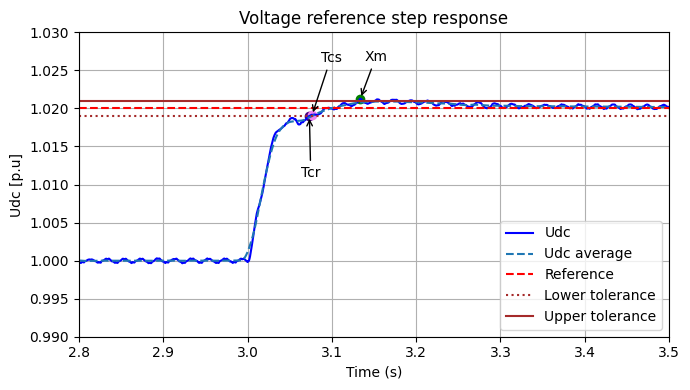

In [81]:
plot_signal_analysis(files[100], settling_window=200)

### Run Test

In [83]:
csv_files = glob.glob("..\\output\\simulation_results\\step_up_voltage_ref_response\\*.csv")
delta_u = 12.8
result_summary = []
for file in csv_files:
    test_var = 1
    try:
        results = analyze_signal(file)
    except IndexError:
        print(file)
        continue
    result_df = results["df"]
    if results["Xm"] > 0.2*delta_u:
        test_var = 0
    elif results["Tcr"] > 0.2:
        test_var = 0
    elif results["Tcs"] > 0.3:
        test_var = 0
    result_df["Xm"] = results["Xm"]
    result_df["Tcr"] = results["Tcr"]
    result_df["Tcs"] = results["Tcs"]
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[0,:]]))
result_summary_df = pd.concat(result_summary, axis=0).reset_index(drop=True)
file_path = Path("..\\output\\simulation_results\\step_u_ref_response\\step_up_u_ref_results_summary.csv")
file_path.parent.mkdir(parents=True, exist_ok=True)
result_summary_df.to_csv(file_path, index=True)

In [94]:
result_summary_df.head()

,TIME,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,C_uF,Xm,Tcr,Tcs,score
0,4.9996,1.349598,880.175926,652.8,652.768736,10.0,400.0,1000.0,0.81,0.048,0.050,1.0
1,4.9996,1.360386,887.341670,652.8,652.777272,6.0,400.0,1000.0,1.09,0.050,0.116,1.0
2,4.9996,1.357540,885.781390,652.8,652.766109,7.0,400.0,1000.0,1.01,0.050,0.112,1.0
3,4.9996,1.354897,883.871012,652.8,652.773541,8.0,400.0,1000.0,0.93,0.050,0.107,1.0
4,4.9996,1.351790,882.561606,652.8,652.756455,9.0,400.0,1000.0,0.90,0.048,0.098,1.0


In [85]:
result_summary_df[result_summary_df['score']==1].shape

(350, 12)

In [86]:
result_summary_df.shape

(350, 12)

In [87]:
result_summary_df[result_summary_df['score']==0]

,TIME,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,C_uF,Xm,Tcr,Tcs,score


## Step down 

In [150]:

def analyze_step_down_signal(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=0.98*640,
    tol_factor=0.05,
    band_percent=0.02*640,
    settling_window=200
):
    """
    Analyze a step-down signal from a CSV file.
    Settling time is calculated using a smoothed version of the signal.
    """
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[25000:, :]
    df["R_ohms"] = float(file_path.split("\\")[-1].split("_")[-2][1:])
    df["H_mH"] = float(file_path.split("\\")[-1].split("_")[-4][1:])
    df["C_uF"] = float(file_path.split("\\")[-1].split("_")[-3][1:])
    
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    within_band = (y >= lower) & (y <= upper)

    # -----------------------------
    # MIN VALUE
    # -----------------------------
    min_idx = np.argmin(y)
    min_value = y[min_idx]
    min_time = t[min_idx]

    # -----------------------------
    # TIME TO FALL INTO TOLERANCE BAND
    # -----------------------------
    fall_idx = None
    for i in range(len(y)):
        if within_band[i]:
            fall_idx = i
            break
    fall_time = t[fall_idx] if fall_idx is not None else None

    # -----------------------------
    # SETTLING TIME USING SMOOTH SIGNAL
    # -----------------------------
    y_smooth = smooth_signal(y, window_size=settling_window)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break
    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # RETURN RESULTS
    # -----------------------------
    results = {
        "Tcr": round(fall_time - 3., 3) if fall_time is not None else None,   # time to fall into band
        "Xm": round(target - min_value, 2),                                     # min deviation
        "Tcs": round(settling_time - 3., 3) if settling_time is not None else None,
        "df": df.tail()
    }

    return results


def smooth_signal(y, window_size=50):
    """
    Apply moving average (running average) to smooth signal.
    """
    return pd.Series(y).rolling(window=window_size, center=True, min_periods=1).mean().values


def plot_step_down_signal(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=0.98*640,
    tol_factor=0.05,
    band_percent=0.02*640,
    settling_window=100
):
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[25000:, :]
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    # -----------------------------
    # SMOOTH SIGNAL FOR SETTLING
    # -----------------------------
    y_smooth = smooth_signal(y, window_size=settling_window)
    within_band = (y >= lower) & (y <= upper)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    # -----------------------------
    # TIME TO FALL INTO BAND
    # -----------------------------
    fall_idx = None
    for i in range(len(y)):
        if within_band[i]:
            fall_idx = i
            break
    fall_time = t[fall_idx] if fall_idx is not None else None

    # -----------------------------
    # MIN VALUE
    # -----------------------------
    min_idx = np.argmin(y)
    min_value = y[min_idx]
    min_time = t[min_idx]

    # -----------------------------
    # SETTLING TIME
    # -----------------------------
    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break
    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # PLOTTING
    # -----------------------------
    plt.figure(figsize=(7, 4))
    ax = plt.gca()
    plt.plot(t, y/640, color="blue", label="Udc")
    plt.plot(t, y_smooth/640, linestyle="--", label="Udc average")
    plt.axhline(target/640, linestyle="--", color="red",linewidth=1.5, label="Reference")
    plt.axhline(lower/640, linestyle=":", color="brown",linewidth=1.5, label="Lower tolerance")
    plt.axhline(upper/640, linestyle="-", color="brown",linewidth=1.5, label="Upper tolerance")

    if fall_time is not None:
        plt.scatter(fall_time, y[fall_idx]/640)
        plt.annotate(
            "Tcr",
            (fall_time, y[fall_idx]/640),
            xytext=(fall_time - 0.09, y[fall_idx]/640 + 0.008),
            arrowprops=dict(arrowstyle="->")
        )

    plt.scatter(min_time, min_value/640)
    plt.annotate(
            "Xm",
            (min_time, min_value/640),
            xytext=(min_time + 0.005, min_value/640 + 0.006),
            arrowprops=dict(arrowstyle="->")
        )

    if settling_time is not None:
        plt.scatter(settling_time, y[settling_idx]/640)
        plt.annotate(
            "Tcs",
            (settling_time, y[settling_idx]/640),
            xytext=(settling_time + 0.01, y[settling_idx]/640 + 0.007),
            arrowprops=dict(arrowstyle="->")
        )

    plt.xlabel("Time (s)")
    plt.ylabel("Udc [p.u]")
    plt.title("Voltage reference step response")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.legend(loc=1)
    plt.ylim([0.97, 1.005])
    plt.xlim([2.8, 3.5])
    plt.grid()
    
    file_path = Path("../output/simulation_results/step_u_ref_response/step_down.png")
    file_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(file_path)
    
    plt.show()

In [108]:
files = glob.glob("..\\output\\simulation_results\\step_down_voltage_ref_response\\*.csv")

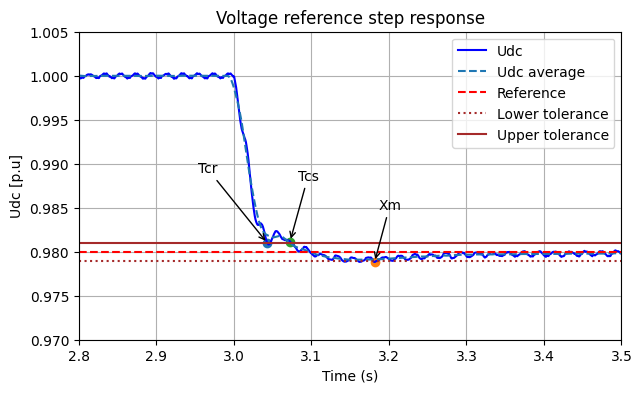

In [151]:
plot_step_down_signal(files[100], settling_window=200)

### Run Test

In [110]:
csv_files = glob.glob("..\\output\\simulation_results\\step_down_voltage_ref_response\\*.csv")
delta_u = 12.8
result_summary = []
for file in csv_files:
    test_var = 1
    try:
        results = analyze_step_down_signal(file)
    except IndexError:
        print(file)
        continue
    result_df = results["df"]
    if results["Xm"] > 0.2*delta_u:
        test_var = 0
    elif results["Tcr"] > 0.2:
        test_var = 0
    elif results["Tcs"] > 0.3:
        test_var = 0
    # elif not results["response_ok"]:
    #     test_var = 0
    result_df["Xm"] = results["Xm"]
    result_df["Tcr"] = results["Tcr"]
    result_df["Tcs"] = results["Tcs"]
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[0,:]]))
result_summary_df = pd.concat(result_summary, axis=0).reset_index(drop=True)
file_path = Path("..\\output\\simulation_results\\step_u_ref_response\\step_down_u_ref_results_summary.csv")
file_path.parent.mkdir(parents=True, exist_ok=True)
result_summary_df.to_csv(file_path, index=True)

In [111]:
result_summary_df.head()

,TIME,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,C_uF,Xm,Tcr,Tcs,score
0,4.9996,1.402257,878.975492,627.2,627.148272,10.0,400.0,1000.0,0.82,0.042,0.048,1.0
1,4.9996,1.414300,886.608161,627.2,627.192451,6.0,400.0,1000.0,1.03,0.045,0.112,1.0
2,4.9996,1.411449,884.421585,627.2,627.190609,7.0,400.0,1000.0,0.98,0.044,0.109,1.0
3,4.9996,1.408075,882.967294,627.2,627.154158,8.0,400.0,1000.0,0.89,0.043,0.103,1.0
4,4.9996,1.405477,880.575444,627.2,627.118712,9.0,400.0,1000.0,0.88,0.042,0.094,1.0


In [112]:
result_summary_df.shape

(350, 12)

In [113]:
result_summary_df[result_summary_df['score']==1].shape

(350, 12)

## Combined result summary

In [114]:
summary_files = glob.glob("..\\output\\simulation_results\\step_u_ref_response\\step*.csv")
summary_files

['..\\output\\simulation_results\\step_u_ref_response\\step_down_u_ref_results_summary.csv',
 '..\\output\\simulation_results\\step_u_ref_response\\step_up_u_ref_results_summary.csv']

In [115]:
df1 = pd.read_csv(summary_files[0], index_col=0)
df1 = df1.drop(columns=['TIME'])
df1 = df1[df1['score'] == 1]
df1.head()

,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,C_uF,Xm,Tcr,Tcs,score
0,1.402257,878.975492,627.2,627.148272,10.0,400.0,1000.0,0.82,0.042,0.048,1.0
1,1.414300,886.608161,627.2,627.192451,6.0,400.0,1000.0,1.03,0.045,0.112,1.0
2,1.411449,884.421585,627.2,627.190609,7.0,400.0,1000.0,0.98,0.044,0.109,1.0
3,1.408075,882.967294,627.2,627.154158,8.0,400.0,1000.0,0.89,0.043,0.103,1.0
4,1.405477,880.575444,627.2,627.118712,9.0,400.0,1000.0,0.88,0.042,0.094,1.0


In [116]:
df2 = pd.read_csv(summary_files[1], index_col=0)
df2 = df2.drop(columns=['TIME'])
df2 = df2[df2['score'] == 1]
df2.head()

,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,C_uF,Xm,Tcr,Tcs,score
0,1.349598,880.175926,652.8,652.768736,10.0,400.0,1000.0,0.81,0.048,0.050,1.0
1,1.360386,887.341670,652.8,652.777272,6.0,400.0,1000.0,1.09,0.050,0.116,1.0
2,1.357540,885.781390,652.8,652.766109,7.0,400.0,1000.0,1.01,0.050,0.112,1.0
3,1.354897,883.871012,652.8,652.773541,8.0,400.0,1000.0,0.93,0.050,0.107,1.0
4,1.351790,882.561606,652.8,652.756455,9.0,400.0,1000.0,0.90,0.048,0.098,1.0


In [117]:
merged_df = pd.merge(
    df1,
    df2,
    on=['R_ohms', 'H_mH', 'C_uF'],   # columns to match on
    how='inner',           # change to 'left', 'right', or 'outer' if needed
    suffixes=('_u_down', '_u_up')
)

In [118]:
merged_df.drop(columns=['Vdc_ref_u_up', 'score_u_down'], inplace=True)
merged_df.rename(columns={'score_u_up': 'score'}, inplace=True)
merged_df.to_csv('..\\output\\simulation_results\\step_u_ref_response\\successful_tests.csv', index=False)

In [119]:
merged_df.head()

,Idc_u_down,Pac_u_down,Vdc_ref_u_down,Vdc_u_down,R_ohms,H_mH,C_uF,Xm_u_down,Tcr_u_down,Tcs_u_down,Idc_u_up,Pac_u_up,Vdc_u_up,Xm_u_up,Tcr_u_up,Tcs_u_up,score
0,1.402257,878.975492,627.2,627.148272,10.0,400.0,1000.0,0.82,0.042,0.048,1.349598,880.175926,652.768736,0.81,0.048,0.050,1.0
1,1.414300,886.608161,627.2,627.192451,6.0,400.0,1000.0,1.03,0.045,0.112,1.360386,887.341670,652.777272,1.09,0.050,0.116,1.0
2,1.411449,884.421585,627.2,627.190609,7.0,400.0,1000.0,0.98,0.044,0.109,1.357540,885.781390,652.766109,1.01,0.050,0.112,1.0
3,1.408075,882.967294,627.2,627.154158,8.0,400.0,1000.0,0.89,0.043,0.103,1.354897,883.871012,652.773541,0.93,0.050,0.107,1.0
4,1.405477,880.575444,627.2,627.118712,9.0,400.0,1000.0,0.88,0.042,0.094,1.351790,882.561606,652.756455,0.90,0.048,0.098,1.0


## Plots

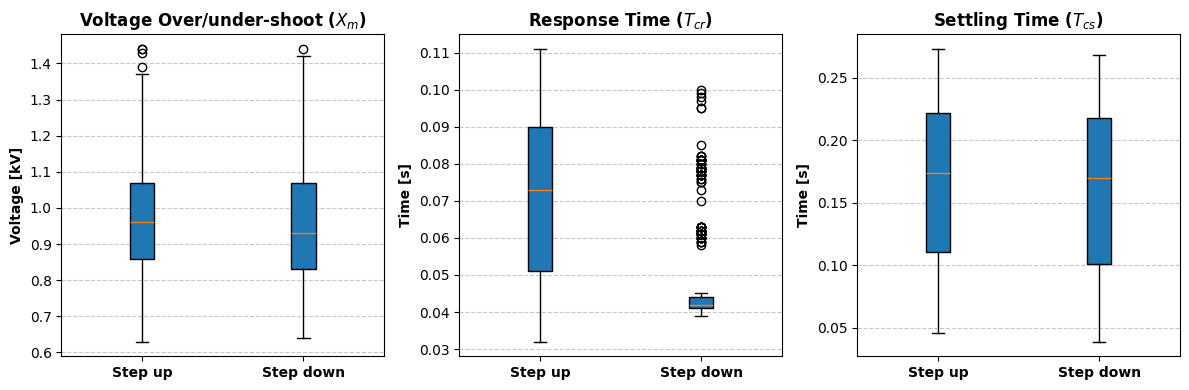

In [148]:
def plot_boxplots(df: pd.DataFrame):
    """
    Plots Xm, Tcs, and Tcr in separate subplots.
    """

    xm = df[["Xm_u_up", "Xm_u_down"]]
    tcs = df[["Tcs_u_up", "Tcs_u_down"]]
    tcr = df[["Tcr_u_up", "Tcr_u_down"]]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # -------------------------
    # Subplot 1: Xm
    # -------------------------
    axes[0].boxplot(xm.values, tick_labels=["Step up", "Step down"], patch_artist=True)
    axes[0].set_title(r"Voltage Over/under-shoot ($X_{m}$)", fontweight='bold')
    axes[0].set_ylabel("Voltage [kV]", fontweight='bold')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    for label in axes[0].get_xticklabels():
        label.set_fontweight('bold')

    # -------------------------
    # Subplot 2: Tcr
    # -------------------------
    axes[1].boxplot(tcr.values, tick_labels=["Step up", "Step down"], patch_artist=True)
    axes[1].set_title(r"Response Time ($T_{cr}$)", fontweight='bold')
    axes[1].set_ylabel("Time [s]", fontweight='bold')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    for label in axes[1].get_xticklabels():
        label.set_fontweight('bold')

    # -------------------------
    # Subplot 3: Tcs
    # -------------------------
    axes[2].boxplot(tcs.values, tick_labels=["Step up", "Step down"], patch_artist=True)
    axes[2].set_title(r"Settling Time ($T_{cs}$)", fontweight='bold')
    axes[2].set_ylabel("Time [s]", fontweight='bold')
    axes[2].grid(axis='y', linestyle='--', alpha=0.7)
    for label in axes[2].get_xticklabels():
        label.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(r"..\output\simulation_results\step_u_ref_response\test_plot.pdf")
    plt.show()


if __name__ == "__main__":
    plot_boxplots(merged_df)